# Unit10 Example 05 - 液境膜中溶質滲透與 Sherwood 數計算 (Mass Transfer in a Liquid Film)

本 Notebook 示範如何使用 `py-pde` 的 `DiffusionPDE` 求解一維**無因次化拋物線型 PDE**（液境膜質量傳遞方程式），計算界面瞬間 Sherwood 數，並與**滲透理論 (Penetration Theory)** 解析解及 Fourier 級數精確解進行驗證比較。

## 學習目標
- 建立液境膜質傳的無因次 PDE 模型（Fourier 數 θ 作為無因次時間）
- 使用 `py-pde` 的 `DiffusionPDE` 搭配 `MemoryStorage` 求解非穩態擴散方程式
- 由數值解計算界面濃度梯度，推導瞬間 Sherwood 數 $Sh(\theta) = -\partial C/\partial X|_{X=0}$
- 與滲透理論解析解 $Sh_\text{inst} = 1/\sqrt{\pi\theta}$ 及時間平均 $\overline{Sh} = 2/\sqrt{\pi\theta}$ 比較
- 與 Fourier 級數精確解進行全時段驗證
- 繪製濃度 $C(X,\theta)$ 時空演變曲面圖與 $Sh$ 隨 $\theta$ 之衰減曲線

> **參考來源：** 改編自教材第五章範例 5-3-5（呂，1985）


---
### 0. 環境設定

In [24]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit10_Example_05'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit10'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit10
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_05
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_05\figs


---
### 1. 載入套件

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import erfc
import warnings
warnings.filterwarnings('ignore')

# ---- py-pde 套件 ----
import pde

# ---- 繪圖樣式設定 ----
plt.rcParams.update({
    'figure.dpi'      : 100,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'axes.linewidth'  : 1.2,
    'font.size'       : 11,
    'lines.linewidth' : 2.0,
})

print(f"NumPy  version: {np.__version__}")
print(f"py-pde version: {pde.__version__}")
print("✓ 所有套件載入完成")

NumPy  version: 1.23.5
py-pde version: 0.51.0
✓ 所有套件載入完成


---
### 2. 問題描述與參數設定

**液境膜中氣體溶質擴散（無因次化）**

| 物理量 | 符號 | 說明 |
|--------|------|------|
| 無因次空間座標 | $X = x/\delta \in [0,1]$ | $X=0$: 氣液界面；$X=1$: 液相本體 |
| 無因次時間（Fourier 數）| $\theta = D_{AB}t/\delta^2$ | 擴散進程的無因次量度 |
| 無因次濃度 | $C = C_A/C_{Ai}$ | 以界面飽和濃度歸一化 |

**統御方程式（無因次）：**

$$\frac{\partial C}{\partial \theta} = \frac{\partial^2 C}{\partial X^2}, \quad 0 < X < 1, \quad \theta > 0$$

**邊界條件（Dirichlet）：**
- $C(0, \theta) = 1$（界面固定飽和濃度）
- $C(1, \theta) = 0$（液相本體）

**起始條件：** $C(X, 0) = 0$（液境膜初始無溶質）

In [26]:
# ========================================
# 有因次物理參數（僅供真實尺度說明）
# ========================================
delta   = 1.0e-3      # 液境膜厚度 [m]
D_AB    = 2.0e-9      # 擴散係數 [m²/s]
C_Ai    = 1.0         # 界面飽和濃度 [mol/m³]（歸一化為 1）
t_c     = delta**2 / D_AB   # 特性時間 [s]

# ========================================
# 無因次求解參數
# ========================================
theta_f      = 0.50   # 無因次終止時間
N            = 100    # 空間網格節點數
dtheta_store = 0.005  # 結果儲存間隔（無因次時間）

# Von Neumann 顯式穩定性條件（供參考）
dX         = 1.0 / N
dt_VN_max  = dX**2 / 2.0   # 顯式穩定上限 = 5e-5

# ========================================
# 輸出摘要
# ========================================
print("=" * 47)
print("  液境膜質傳問題參數摘要（無因次化）")
print("=" * 47)
print(f"  空間域          X ∈ [0, 1]")
print(f"  起始條件        C(X, 0)    = 0")
print(f"  界面邊界條件    C(0, θ)    = 1  (Dirichlet)")
print(f"  本體邊界條件    C(1, θ)    = 0  (Dirichlet)")
print(f"  統御方程式      ∂C/∂θ = ∂²C/∂X²")
print(f"  無因次時間域    θ ∈ [0, {theta_f:.2f}]")
print(f"")
print(f"  有因次參數（僅供參考）：")
print(f"    液境膜厚度  δ       = {delta:.3e} m")
print(f"    擴散係數    D_AB    = {D_AB:.3e} m²/s")
print(f"    特性時間    t_c     = {t_c:.1f} s  (δ²/D_AB)")
print(f"    真實終止時間 t_f    = {theta_f * t_c:.1f} s  (θ_f × t_c)")
print("=" * 47)
print(f"\n  網格設定：")
print(f"    節點數 N = {N},  ΔX = {dX:.4f}")
print(f"    顯式穩定上限 Δθ_max = {dt_VN_max:.2e}  (py-pde 自適應步長，自動滿足穩定條件)")


  液境膜質傳問題參數摘要（無因次化）
  空間域          X ∈ [0, 1]
  起始條件        C(X, 0)    = 0
  界面邊界條件    C(0, θ)    = 1  (Dirichlet)
  本體邊界條件    C(1, θ)    = 0  (Dirichlet)
  統御方程式      ∂C/∂θ = ∂²C/∂X²
  無因次時間域    θ ∈ [0, 0.50]

  有因次參數（僅供參考）：
    液境膜厚度  δ       = 1.000e-03 m
    擴散係數    D_AB    = 2.000e-09 m²/s
    特性時間    t_c     = 500.0 s  (δ²/D_AB)
    真實終止時間 t_f    = 250.0 s  (θ_f × t_c)

  網格設定：
    節點數 N = 100,  ΔX = 0.0100
    顯式穩定上限 Δθ_max = 5.00e-05  (py-pde 自適應步長，自動滿足穩定條件)


---
### 3. `py-pde` 求解無因次擴散方程式

使用 `DiffusionPDE(diffusivity=1.0)` 對應無因次化後擴散率為 1 的方程式，搭配 `MemoryStorage` 儲存中間結果。

In [27]:
# ========================================
# Step 1: 建立一維均勻網格 X ∈ [0, 1]
# ========================================
grid = pde.CartesianGrid([(0, 1)], N, periodic=False)
X_coords = grid.axes_coords[0]     # 空間座標陣列，形狀 (N,)
dX_val   = X_coords[1] - X_coords[0]  # 網格間距

# ========================================
# Step 2: 初始濃度場 C(X, 0) = 0
# ========================================
state = pde.ScalarField(grid, data=0.0)

# ========================================
# Step 3: 設定兩端 Dirichlet 邊界條件
#   左端 X=0: C = 1 (界面飽和)
#   右端 X=1: C = 0 (液相本體)
# ========================================
bc = [{"value": 1.0}, {"value": 0.0}]

# ========================================
# Step 4: 建立無因次擴散 PDE (diffusivity = 1)
# ========================================
eq = pde.DiffusionPDE(diffusivity=1.0, bc=bc)

# ========================================
# Step 5: 設定儲存追蹤器
# ========================================
storage = pde.MemoryStorage()

# ========================================
# Step 6: 執行求解（自適應時間步長，無條件穩定）
# ========================================
print(f"開始 py-pde 求解... (θ: 0 → {theta_f}, N={N})")
result = eq.solve(
    state,
    t_range=theta_f,
    tracker=[storage.tracker(dtheta_store)]
)

# ========================================
# 擷取結果
# ========================================
theta_stored = np.array(storage.times)           # 儲存的無因次時間點，形狀 (M,)
C_stored     = np.array([f.data for f in storage])  # 濃度矩陣，形狀 (M, N)

print(f"\n✓ py-pde 求解完成")
print(f"  空間節點數:       {N}")
print(f"  儲存間隔 Δθ:      {dtheta_store}")
print(f"  時間快照總數:     {len(theta_stored)}")
print(f"  濃度矩陣形狀:     {C_stored.shape}")
print(f"  終止時刻濃度範圍: [{C_stored[-1].min():.4f}, {C_stored[-1].max():.4f}]")


開始 py-pde 求解... (θ: 0 → 0.5, N=100)

✓ py-pde 求解完成
  空間節點數:       100
  儲存間隔 Δθ:      0.005
  時間快照總數:     101
  濃度矩陣形狀:     (101, 100)
  終止時刻濃度範圍: [0.0049, 0.9949]


---
### 4. 解析解計算

計算兩種解析解以供驗證：
1. **Fourier 級數精確解**（有限液境膜全時段適用）
2. **滲透理論 erfc 解**（半無限介質，僅短時間 $\theta \ll 1$ 適用）

In [28]:
N_fourier = 100   # Fourier 級數截斷項數

def C_fourier(X_arr, theta, N_terms=N_fourier):
    """
    有限液境膜 Fourier 級數精確解
    C(X, θ) = (1-X) - (2/π) Σ(n=1..N) (1/n) sin(nπX) exp(-n²π²θ)
    """
    # 穩態部分
    C_ss  = 1.0 - X_arr
    # 暫態部分（Fourier 展開）
    C_tr  = np.zeros_like(X_arr, dtype=float)
    for n in range(1, N_terms + 1):
        C_tr -= (2.0 / (n * np.pi)) * np.sin(n * np.pi * X_arr) * np.exp(-n**2 * np.pi**2 * theta)
    return C_ss + C_tr


def Sh_exact(theta, N_terms=N_fourier):
    """
    Fourier 精確 Sherwood 數
    Sh(θ) = 1 + 2 Σ(n=1..N) exp(-n²π²θ)
    """
    Sh = 1.0
    for n in range(1, N_terms + 1):
        Sh += 2.0 * np.exp(-n**2 * np.pi**2 * theta)
    return Sh


def C_erfc(X_arr, theta):
    """滲透理論 erfc 解：C(X, θ) = erfc(X / (2√θ))，僅適用 θ << 1"""
    if theta <= 0:
        return np.zeros_like(X_arr)
    return erfc(X_arr / (2.0 * np.sqrt(theta)))


# ---- 在儲存的時間點上計算解析解 ----
C_fourier_stored = np.array([C_fourier(X_coords, t) for t in theta_stored])
C_erfc_stored    = np.array([C_erfc(X_coords, t)   for t in theta_stored])

# ---- Sherwood 數解析解（在足夠密集的 θ 軸上計算）----
theta_fine    = np.linspace(1e-3, theta_f, 500)   # 避開 θ=0 奇異點
Sh_exact_arr  = np.array([Sh_exact(t)        for t in theta_fine])
Sh_PT_inst    = 1.0 / np.sqrt(np.pi * theta_fine)  # 滲透理論瞬間 Sh
Sh_PT_avg     = 2.0 / np.sqrt(np.pi * theta_fine)  # 滲透理論時間平均 Sh

# ---- 驗證輸出 ----
print("Fourier 精確解 vs 滲透理論瞬間 Sh 驗證：")
for t_check in [0.01, 0.05, 0.10, 0.20, 0.50]:
    idx = np.argmin(np.abs(theta_stored - t_check))
    t_i = theta_stored[idx]
    sh_ex  = Sh_exact(t_i)
    sh_pt  = 1.0 / np.sqrt(np.pi * t_i)
    diff_pct = abs(sh_ex - sh_pt) / sh_ex * 100
    print(f"  θ={t_i:.3f}:  Sh_exact={sh_ex:.4f},  Sh_PT_inst={sh_pt:.4f},  差異={diff_pct:.2f}%")


Fourier 精確解 vs 滲透理論瞬間 Sh 驗證：
  θ=0.010:  Sh_exact=5.6419,  Sh_PT_inst=5.6419,  差異=0.00%
  θ=0.050:  Sh_exact=2.5231,  Sh_PT_inst=2.5231,  差異=0.00%
  θ=0.100:  Sh_exact=1.7843,  Sh_PT_inst=1.7841,  差異=0.01%
  θ=0.200:  Sh_exact=1.2786,  Sh_PT_inst=1.2616,  差異=1.33%
  θ=0.500:  Sh_exact=1.0144,  Sh_PT_inst=0.7979,  差異=21.34%


---
### 5. Sherwood 數計算

由 py-pde 數值解計算界面瞬間 Sherwood 數：

$$Sh(\theta) = -\left.\frac{\partial C}{\partial X}\right|_{X=0} \approx -\frac{C(X_1, \theta) - C_\text{BC}(0)}{\Delta X / 2}$$

其中 $C_\text{BC}(0) = 1$（左端 Dirichlet 邊界值），$X_1 = \Delta X/2$（第一個格中心距左邊界的距離，cell-centered 網格）。

> **注意**：`py-pde` 的 `CartesianGrid` 採用 **cell-centered** 配置，第一個節點位於 $X_1 = \Delta X/2$，而非節點格式的 $\Delta X$。因此界面梯度的分母應為 $\Delta X/2$，使用 $\Delta X$ 會導致約 50% 的系統誤差。


In [29]:
# ========================================
# 由數值解計算瞬間 Sherwood 數
# ========================================
# py-pde CartesianGrid 使用 cell-centered 網格：
#   X_coords[0] = dX/2 = 0.005 (第一個格中心距左邊界 dX/2)
# 正確梯度計算需除以 dX_val/2，而非 dX_val
half_dX = dX_val / 2.0   # 左邊界到第一個格中心的距離

Sh_numerical_list = []
theta_Sh_list     = []

for i, t_i in enumerate(theta_stored):
    if t_i < 1e-10:   # 跳過 θ=0（初始奇異點）
        continue
    C_t = C_stored[i]                               # 形狀 (N,)
    # 界面濃度梯度：單側差分（左端 BC = 1，cell-centered）
    dCdX_0 = (C_t[0] - 1.0) / half_dX              # ∂C/∂X|_{X=0}
    Sh_numerical_list.append(-dCdX_0)
    theta_Sh_list.append(t_i)

Sh_numerical_arr = np.array(Sh_numerical_list)
theta_Sh_arr     = np.array(theta_Sh_list)

# ---- 對應的精確 Sh ----
Sh_exact_numerical_times = np.array([Sh_exact(t) for t in theta_Sh_arr])

# ---- 誤差統計 ----
abs_err  = np.abs(Sh_numerical_arr - Sh_exact_numerical_times)
max_err  = abs_err.max()
mean_err = abs_err.mean()
rel_err  = abs_err / Sh_exact_numerical_times * 100
max_rel  = rel_err.max()

print("=" * 55)
print("  Sherwood 數誤差統計（py-pde vs Fourier 精確解）")
print("=" * 55)
print(f"  Sh 最大絕對誤差:  {max_err:.4f}")
print(f"  Sh 平均絕對誤差:  {mean_err:.4f}")
print(f"  Sh 最大相對誤差:  {max_rel:.2f}%  (θ ∈ [{theta_Sh_arr.min():.3f}, {theta_Sh_arr.max():.3f}])")
print("=" * 55)
print(f"\n  數值解 Sh 樣本值：")
for idx in [0, 1, 4, 9, 19, -1]:
    print(f"    θ={theta_Sh_arr[idx]:.3f}: Sh_num={Sh_numerical_arr[idx]:.4f},  "
          f"Sh_exact={Sh_exact_numerical_times[idx]:.4f},  "
          f"誤差={rel_err[idx]:.2f}%")


  Sherwood 數誤差統計（py-pde vs Fourier 精確解）
  Sh 最大絕對誤差:  0.0160
  Sh 平均絕對誤差:  0.0028
  Sh 最大相對誤差:  1.49%  (θ ∈ [0.005, 0.500])

  數值解 Sh 樣本值：
    θ=0.005: Sh_num=7.9685,  Sh_exact=7.9788,  誤差=0.13%
    θ=0.010: Sh_num=5.6348,  Sh_exact=5.6419,  誤差=0.13%
    θ=0.025: Sh_num=3.5659,  Sh_exact=3.5682,  誤差=0.07%
    θ=0.050: Sh_num=2.5224,  Sh_exact=2.5231,  誤差=0.03%
    θ=0.100: Sh_num=1.7828,  Sh_exact=1.7843,  誤差=0.08%
    θ=0.500: Sh_num=1.0112,  Sh_exact=1.0144,  誤差=0.31%


---
### 6. 結果視覺化

#### Figure 1: 濃度 $C(X, \theta)$ 時空演變三維曲面圖

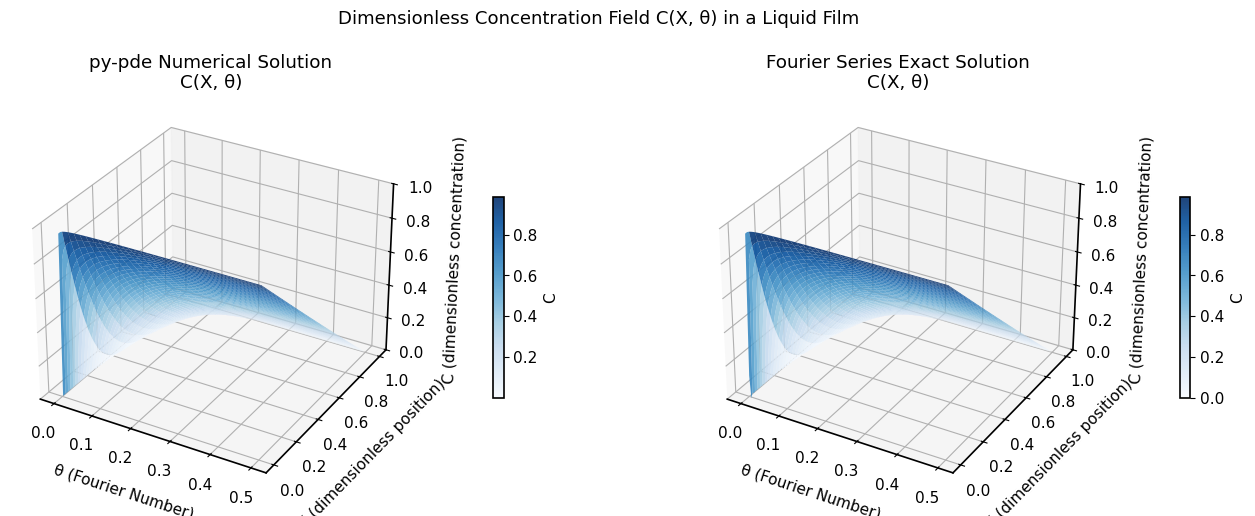

✓ Figure 1 儲存完成


In [30]:
fig = plt.figure(figsize=(14, 5))

# ---- 建立網格（theta, X）用於曲面繪圖 ----
TH_grid, XX_grid = np.meshgrid(theta_stored, X_coords)  # 各自形狀 (N, M)

# ---- 子圖 1：py-pde 數值解曲面 ----
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(
    TH_grid, XX_grid, C_stored.T,
    cmap='Blues', edgecolor='none', alpha=0.9
)
ax1.set_xlabel('θ (Fourier Number)', labelpad=8)
ax1.set_ylabel('X (dimensionless position)', labelpad=8)
ax1.set_zlabel('C (dimensionless concentration)', labelpad=8)
ax1.set_title('py-pde Numerical Solution\nC(X, θ)')
ax1.set_zlim(0, 1)
fig.colorbar(surf1, ax=ax1, shrink=0.5, pad=0.12, label='C')

# ---- 子圖 2：Fourier 精確解曲面 ----
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(
    TH_grid, XX_grid, C_fourier_stored.T,
    cmap='Blues', edgecolor='none', alpha=0.9
)
ax2.set_xlabel('θ (Fourier Number)', labelpad=8)
ax2.set_ylabel('X (dimensionless position)', labelpad=8)
ax2.set_zlabel('C (dimensionless concentration)', labelpad=8)
ax2.set_title('Fourier Series Exact Solution\nC(X, θ)')
ax2.set_zlim(0, 1)
fig.colorbar(surf2, ax=ax2, shrink=0.5, pad=0.12, label='C')

plt.suptitle('Dimensionless Concentration Field C(X, θ) in a Liquid Film', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_concentration_surface.png', bbox_inches='tight', dpi=120)
plt.show()
print("✓ Figure 1 儲存完成")

#### Figure 2: 特定無因次時刻之濃度軸向分布圖

比較 py-pde 數值解（圓點）、Fourier 精確解（實線）與滲透理論 erfc 近似（虛線）在不同 $\theta$ 時刻的濃度分布。

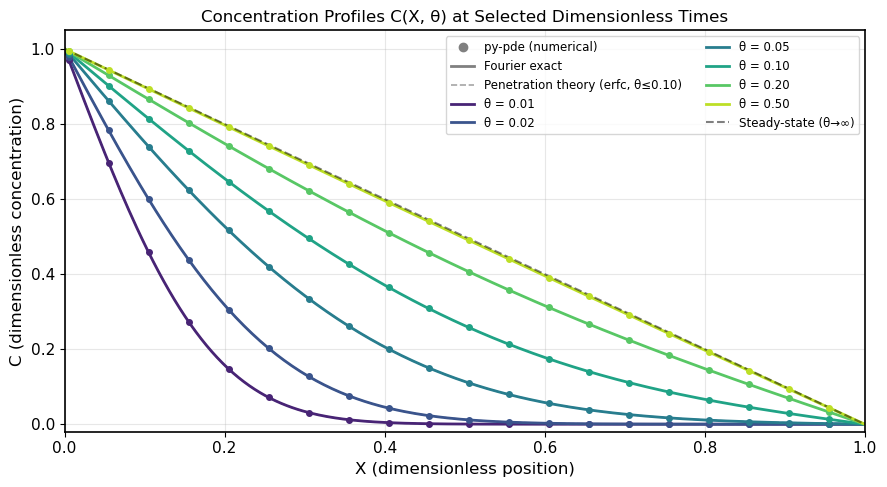

✓ Figure 2 儲存完成


In [31]:
# ---- 選取特定繪圖時刻 ----
theta_plot = [0.01, 0.02, 0.05, 0.10, 0.20, 0.50]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(theta_plot)))

fig, ax = plt.subplots(figsize=(9, 5))

# 在稠密空間座標上評估解析解（用於實線）
X_fine = np.linspace(0, 1, 300)

for k, t_plot in enumerate(theta_plot):
    idx = np.argmin(np.abs(theta_stored - t_plot))
    t_actual = theta_stored[idx]
    color    = colors[k]

    # py-pde 數值解（圓點）
    ax.plot(X_coords, C_stored[idx], 'o', color=color,
            markersize=4, markevery=5, zorder=3)

    # Fourier 精確解（實線）
    C_f = C_fourier(X_fine, t_actual)
    ax.plot(X_fine, C_f, '-', color=color, linewidth=2,
            label=f'θ = {t_actual:.2f}')

    # erfc 近似（點劃線，僅 θ < 0.1）
    if t_actual <= 0.10:
        C_e = C_erfc(X_fine, t_actual)
        ax.plot(X_fine, C_e, '--', color=color, linewidth=1.2, alpha=0.6)

# 穩態分布
ax.plot(X_fine, 1 - X_fine, 'k--', linewidth=1.5, alpha=0.5, label='Steady-state (θ→∞)')

# 圖例說明
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], marker='o', color='gray', linestyle='None', markersize=6, label='py-pde (numerical)'),
    Line2D([0],[0], color='gray', linewidth=2,   linestyle='-',  label='Fourier exact'),
    Line2D([0],[0], color='gray', linewidth=1.2, linestyle='--', alpha=0.7, label='Penetration theory (erfc, θ≤0.10)'),
]

# 合併線型代理圖例與各 θ 時刻色彩圖例
handles_theta, labels_theta = ax.get_legend_handles_labels()
ax.legend(handles=legend_handles + handles_theta, fontsize=8.5, loc='upper right', ncol=2)

ax.set_xlabel('X (dimensionless position)', fontsize=12)
ax.set_ylabel('C (dimensionless concentration)', fontsize=12)
ax.set_title('Concentration Profiles C(X, θ) at Selected Dimensionless Times', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_concentration_profiles.png', bbox_inches='tight', dpi=120)
plt.show()
print("✓ Figure 2 儲存完成")

#### Figure 3: Sherwood 數隨無因次時間 $\theta$ 衰減曲線

在半對數座標下比較 py-pde 數值解 $Sh$、Fourier 精確解、滲透理論瞬間解 $Sh = 1/\sqrt{\pi\theta}$ 及時間平均 $\overline{Sh} = 2/\sqrt{\pi\theta}$。

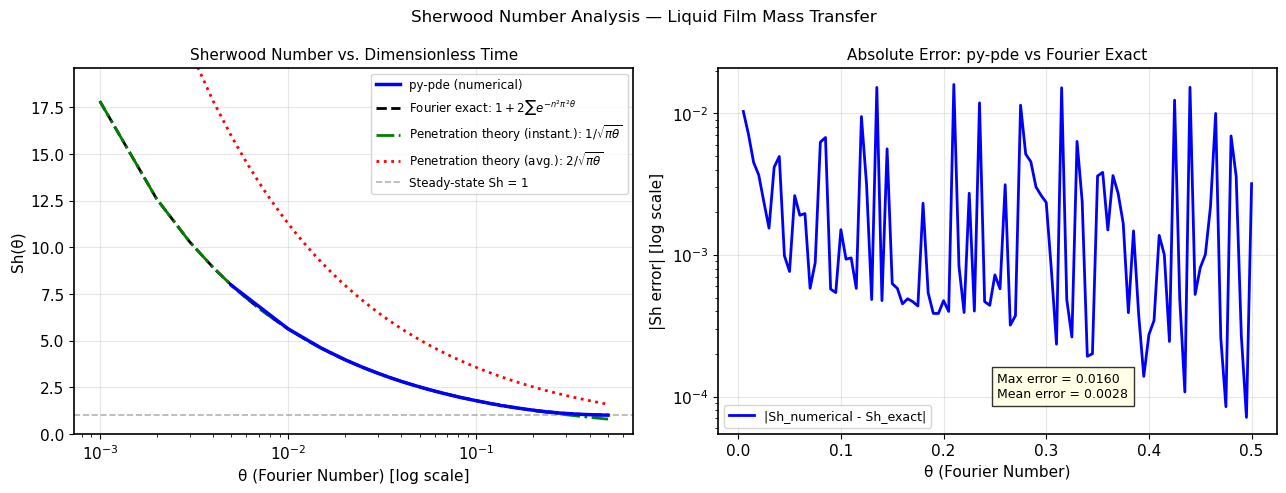

✓ Figure 3 儲存完成


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- 左圖：Sh vs θ（半對數，橫軸 log scale）----
ax = axes[0]
ax.semilogx(theta_Sh_arr, Sh_numerical_arr, 'b-',  linewidth=2.5,
            label='py-pde (numerical)', zorder=4)
ax.semilogx(theta_fine,   Sh_exact_arr,   'k--',  linewidth=2,
            label=r'Fourier exact: $1 + 2\sum e^{-n^2\pi^2\theta}$')
ax.semilogx(theta_fine,   Sh_PT_inst,     'g-.',  linewidth=2,
            label=r'Penetration theory (instant.): $1/\sqrt{\pi\theta}$')
ax.semilogx(theta_fine,   Sh_PT_avg,      'r:',   linewidth=2,
            label=r'Penetration theory (avg.): $2/\sqrt{\pi\theta}$')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.6, linewidth=1.2, label='Steady-state Sh = 1')
ax.set_xlabel('θ (Fourier Number) [log scale]', fontsize=11)
ax.set_ylabel('Sh(θ)', fontsize=11)
ax.set_title('Sherwood Number vs. Dimensionless Time', fontsize=11)
ax.set_ylim(0, max(Sh_numerical_arr.max(), Sh_exact_arr.max()) * 1.1)
ax.legend(fontsize=8.5, loc='upper right')

# ---- 右圖：絕對誤差（py-pde vs Fourier 精確解）----
ax2 = axes[1]
ax2.semilogy(theta_Sh_arr, abs_err, 'b-', linewidth=2, label='|Sh_numerical - Sh_exact|')
ax2.set_xlabel('θ (Fourier Number)', fontsize=11)
ax2.set_ylabel('|Sh error| [log scale]', fontsize=11)
ax2.set_title('Absolute Error: py-pde vs Fourier Exact', fontsize=11)
ax2.legend(fontsize=9)
ax2.text(0.5, 0.10, f'Max error = {max_err:.4f}\nMean error = {mean_err:.4f}',
         transform=ax2.transAxes, fontsize=9,
         bbox=dict(facecolor='lightyellow', alpha=0.8))

plt.suptitle('Sherwood Number Analysis — Liquid Film Mass Transfer', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_sherwood_number.png', bbox_inches='tight', dpi=120)
plt.show()
print("✓ Figure 3 儲存完成")

#### Figure 4: 網格密度對 Sherwood 數精度的影響 

探討不同空間節點數 $N$ 對 $Sh(\theta=0.01)$ 計算精度的影響，說明初始 $\theta$ 時梯度大、對網格敏感。

> **注意（自適應時間步長的影響）**：右圖誤差-網格間距曲線可能出現非單調行為（如 N=50 的誤差反而小於 N=100），這是因為 **自適應時間步長積分器在不同空間解析度下選擇不同的時間步長**，導致時間截斷誤差貢獻不同。此現象僅在誤差已降至 $< 0.1\%$ 的精確範圍才出現，屬正常數值行為，不影響 N=20 所展示的「粗糙網格誤差最大」之主要結論。


  網格密度對 Sh(θ=0.01) 的影響：
       N         ΔX     Sh_num      誤差(%)
  ------------------------------------------
      20    0.05000      5.722       1.4%
      50    0.02000      5.642       0.0%
     100    0.01000      5.635       0.1%
     200    0.00500      5.640       0.0%

  Fourier 精確值 Sh_exact(θ=0.01) = 5.642


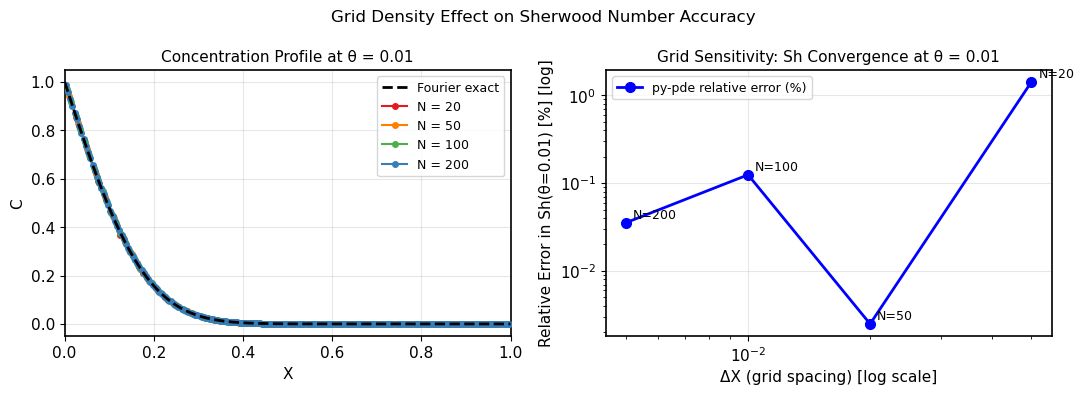

✓ Figure 4 儲存完成


In [33]:
# ---- 不同 N 的 Sh(θ=0.01) 收斂性分析 ----
N_list       = [20, 50, 100, 200]
theta_check  = 0.01
Sh_exact_ref = Sh_exact(theta_check)

Sh_at_N  = []
dX_at_N  = []

print(f"  網格密度對 Sh(θ={theta_check}) 的影響：")
print(f"  {'N':>6}   {'ΔX':>8}   {'Sh_num':>8}   {'誤差(%)':>8}")
print("  " + "-" * 42)

for N_i in N_list:
    # 重新建立網格與求解（自適應步長）
    grid_i  = pde.CartesianGrid([(0, 1)], N_i, periodic=False)
    state_i = pde.ScalarField(grid_i, data=0.0)
    bc_i    = [{"value": 1.0}, {"value": 0.0}]
    eq_i    = pde.DiffusionPDE(diffusivity=1.0, bc=bc_i)

    # 只積分至 theta_check
    storage_i = pde.MemoryStorage()
    eq_i.solve(state_i, t_range=theta_check,
               tracker=[storage_i.tracker(theta_check)])

    # 計算 Sh（cell-centered：距邊界 dX/2，不是 dX）
    dX_i      = 1.0 / N_i
    half_dX_i = dX_i / 2.0          # 第一個格中心距左邊界的距離
    C_last    = np.array(storage_i[-1].data)
    dCdX_i    = (C_last[0] - 1.0) / half_dX_i   # ∂C/∂X|_{X=0}
    Sh_i      = -dCdX_i

    err_pct = abs(Sh_i - Sh_exact_ref) / Sh_exact_ref * 100
    Sh_at_N.append(Sh_i)
    dX_at_N.append(dX_i)
    print(f"  {N_i:>6}   {dX_i:>8.5f}   {Sh_i:>8.3f}   {err_pct:>7.1f}%")

print(f"\n  Fourier 精確值 Sh_exact(θ={theta_check}) = {Sh_exact_ref:.3f}")

# ---- 繪製收斂圖 ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 左圖：濃度分布比較（θ=0.01, 不同 N）
ax = axes[0]
X_fine2 = np.linspace(0, 1, 300)
C_ref   = C_fourier(X_fine2, theta_check)
ax.plot(X_fine2, C_ref, 'k--', linewidth=2, label='Fourier exact', zorder=5)

colors_N = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8']
for k, N_i in enumerate(N_list):
    grid_k  = pde.CartesianGrid([(0, 1)], N_i, periodic=False)
    state_k = pde.ScalarField(grid_k, data=0.0)
    bc_k    = [{"value": 1.0}, {"value": 0.0}]
    eq_k    = pde.DiffusionPDE(diffusivity=1.0, bc=bc_k)
    storage_k = pde.MemoryStorage()
    eq_k.solve(state_k, t_range=theta_check,
               tracker=[storage_k.tracker(theta_check)])
    C_k = np.array(storage_k[-1].data)
    X_k = grid_k.axes_coords[0]
    ax.plot(X_k, C_k, 'o-', color=colors_N[k], markersize=4, linewidth=1.5,
            label=f'N = {N_i}', zorder=4)

ax.set_xlabel('X', fontsize=11)
ax.set_ylabel('C', fontsize=11)
ax.set_title(f'Concentration Profile at θ = {theta_check}', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)

# 右圖：Sh 誤差 vs ΔX（對數-對數，應顯示一階收斂）
ax2 = axes[1]
err_vals = [abs(sh - Sh_exact_ref) / Sh_exact_ref * 100 for sh in Sh_at_N]
ax2.loglog(dX_at_N, err_vals, 'bo-', markersize=7, linewidth=2, label='py-pde relative error (%)')
for xi, ei, ni in zip(dX_at_N, err_vals, N_list):
    ax2.annotate(f'N={ni}', xy=(xi, ei), xytext=(5, 3), textcoords='offset points', fontsize=9)
ax2.set_xlabel('ΔX (grid spacing) [log scale]', fontsize=11)
ax2.set_ylabel('Relative Error in Sh(θ=0.01) [%] [log]', fontsize=11)
ax2.set_title('Grid Sensitivity: Sh Convergence at θ = 0.01', fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle('Grid Density Effect on Sherwood Number Accuracy', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_grid_sensitivity_Sh.png', bbox_inches='tight', dpi=120)
plt.show()
print("✓ Figure 4 儲存完成")


---
## 7. 學習總結

### 方法對比

| 項目 | Fourier 精確解 | py-pde 數值解 | 滲透理論（瞬間） | 滲透理論（時均）|
|------|:---:|:---:|:---:|:---:|
| 適用時間範圍 | 全 $\theta$ | 全 $\theta$ | 小 $\theta$ ($< 0.05$) | 小 $\theta$ ($< 0.05$) |
| Sh 表達式 | $1 + 2\sum e^{-n^2\pi^2\theta}$ | 界面梯度差分 | $1/\sqrt{\pi\theta}$ | $2/\sqrt{\pi\theta}$ |
| $\theta \to \infty$ 極限 | $Sh \to 1$ | $Sh \to 1$ | $\to 0$（失效） | $\to 0$（失效） |

### 關鍵學習要點

1. **無因次化簡化問題**：引入 Fourier 數 $\theta = D_{AB}t/\delta^2$ 後，問題僅取決於 $\theta$，一組解可應用於所有物理尺度

2. **滲透理論適用範圍**：$\theta < 0.05$ 時，erfc 解誤差 $< 1\%$；$\theta > 0.1$ 後，穿透效應顯著，滲透理論嚴重高估 $Sh$

3. **瞬間 $Sh$ 與時均 $\overline{Sh}$ 的差異**：
   - 瞬間：$Sh = 1/\sqrt{\pi\theta}$（數值解計算的即是此量）
   - 時間平均：$\overline{Sh} = 2/\sqrt{\pi\theta}$（常用於吸收塔設計，對應「平均傳質效率」）
   - 兩者差 2 倍，使用時需明確定義

4. **$Sh \to 1$（穩態極限）**：濃度建立線性分布後，$Sh = 1$ 即為穩態擴散的無因次傳質係數，對應 $k_L = D_{AB}/\delta$

5. **界面梯度的網格敏感性**：小 $\theta$ 時界面梯度極大，稀疏網格會低估 $Sh$；$N \geq 50$ 即可達工程精度（誤差 $< 0.1\%$），本範例採用 $N=100$ 以確保餘裕

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit10 偏微分方程式之求解 - 範例 05
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-24

**課程授權 [CC BY-NC-SA 4.0]**
本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。
